In [20]:
import copy
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yfinance as yf
from IPython.display import display
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from xrfm import xRFM

# Targeted filters only -- do not blanket-silence warnings.
warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

#  Constants
SEED          = 42
TARGET_WINDOW = 5  # forward realised-vol horizon (trading days)
TICKERS       = ["SPY", "QQQ", "IWM", "EFA", "TLT", "GLD"]
DATE_START    = "2004-01-01"
DATE_END      = "2024-01-01"
CACHE_DIR     = Path("./cache")
TARGET_SCALE  = 10000.0 # bp^2 scaling, purely for log readability;

CACHE_DIR.mkdir(exist_ok=True)
np.random.seed(SEED)

FEATURE_NAMES = [
    "vol_5d", "vol_21d", "mom_5d", "mom_21d",
    "ma_dist_20d", "ma_dist_50d", "vol_surge_5d",
]

In [21]:
class SklearnCompatibleXRFM(BaseEstimator, RegressorMixin):
    """Minimal scikit-learn wrapper around the xRFM regressor
    """

    def __init__(self, bandwidth=1.0, reg=1e-3, iters=3, rfm_iters=1,
                 n_trees=5, internal_val_frac=0.2, random_state=42):
        self.bandwidth         = bandwidth
        self.reg               = reg
        self.iters             = iters
        self.rfm_iters         = rfm_iters
        self.n_trees           = n_trees
        self.internal_val_frac = internal_val_frac
        self.random_state      = random_state

    def fit(self, X, y):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        rfm_params = {
            "model": {
                "kernel":         "l2",
                "bandwidth":      self.bandwidth,
                "bandwidth_mode": "constant",
            },
            "fit": {
                "reg":     self.reg,
                "iters":   self.rfm_iters,
                "verbose": False,
            },
        }

        self.model_ = xRFM(
            task          = "regression",
            n_trees       = self.n_trees,
            n_tree_iters  = self.iters,
            rfm_params    = rfm_params,
            device        = device,
            tuning_metric = "mse",
            min_subset_size = 7500
        )

        # Chronological inner split
        split = int(len(X) * (1.0 - self.internal_val_frac))
        X_tr, X_v = X[:split], X[split:]
        y_tr, y_v = y[:split], y[split:]

        # xRFM expects a 2D target -> pad with zeros
        y_tr_pad = np.stack([y_tr, np.zeros_like(y_tr)], axis=1)
        y_v_pad  = np.stack([y_v,  np.zeros_like(y_v)],  axis=1)

        self.model_.fit(X_tr, y_tr_pad, X_v, y_v_pad)
        return self

    def predict(self, X):
        preds = self.model_.predict(X)
        if hasattr(preds, "cpu"):
            preds = preds.cpu().numpy()
        if preds.ndim == 2 and preds.shape[1] == 2:
            return preds[:, 0]
        return preds

In [22]:
def load_ticker_data(ticker, start, end, cache_dir):
    """Download OHLCV for one ticker, or read from parquet cache if present."""
    cache_path = cache_dir / f"{ticker}_{start}_{end}.parquet"
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    if raw.empty:
        return None

    df = raw.reset_index()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    df = df[["Date", "Close", "Volume"]].copy()
    df["Ticker"] = ticker
    df.to_parquet(cache_path, index=False)
    return df


def engineer_features(ticker_df, target_window, target_scale):
    """Compute volatility / momentum / moving-average features for one ticker."""
    df = ticker_df.copy()
    df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))

    # Historical realised volatility
    df["vol_5d"]  = np.sqrt((df["log_ret"] ** 2).rolling(5).sum())
    df["vol_21d"] = np.sqrt((df["log_ret"] ** 2).rolling(21).sum())

    # Momentum
    df["mom_5d"]  = df["Close"] / df["Close"].shift(5)  - 1
    df["mom_21d"] = df["Close"] / df["Close"].shift(21) - 1

    # Moving-average distance
    df["ma_dist_20d"] = df["Close"] / df["Close"].rolling(20).mean() - 1
    df["ma_dist_50d"] = df["Close"] / df["Close"].rolling(50).mean() - 1

    # Volume surge
    df["vol_surge_5d"] = df["Volume"] / df["Volume"].rolling(5).mean() - 1

    # Target: forward realised vol over the next 'target_window' trading days.
    df["target_volatility"] = (
        np.sqrt((df["log_ret"] ** 2).rolling(target_window).sum())
          .shift(-target_window) * target_scale
    )
    return df.dropna()


print("Fetching and engineering macro ETF data...")
frames = []
for ticker in TICKERS:
    raw = load_ticker_data(ticker, DATE_START, DATE_END, CACHE_DIR)
    if raw is None:
        print(f"  skipped (no data): {ticker}")
        continue
    frames.append(engineer_features(raw, TARGET_WINDOW, TARGET_SCALE))

master_df = pd.concat(frames).sort_values("Date").reset_index(drop=True)

print(f"Total rows after feature engineering : {len(master_df):,}")
print(f"Unique trading dates                 : {master_df['Date'].nunique():,}")

Fetching and engineering macro ETF data...
Total rows after feature engineering : 29,652
Unique trading dates                 : 4,979


In [23]:
#  Date-based chronological split
unique_dates = np.array(sorted(master_df["Date"].unique()))
n_dates      = len(unique_dates)

train_end_idx = int(n_dates * 0.6)
val_end_idx   = int(n_dates * 0.8)

train_end_date = unique_dates[train_end_idx]
val_end_date   = unique_dates[val_end_idx]

# Drop the TARGET_WINDOW dates immediately before each split edge
train_cutoff_date = unique_dates[train_end_idx - TARGET_WINDOW]
val_cutoff_date   = unique_dates[val_end_idx   - TARGET_WINDOW]

dates = master_df["Date"]
train_mask = dates < train_cutoff_date
val_mask   = (dates >= train_end_date) & (dates < val_cutoff_date)
test_mask  = dates >= val_end_date

train_df = master_df[train_mask]
val_df   = master_df[val_mask]
test_df  = master_df[test_mask]

X_train = train_df[FEATURE_NAMES].values
y_train = train_df["target_volatility"].values
X_val   = val_df[FEATURE_NAMES].values
y_val   = val_df["target_volatility"].values
X_test  = test_df[FEATURE_NAMES].values
y_test  = test_df["target_volatility"].values

print(f"Train : {len(X_train):>6,}  (up to {pd.Timestamp(train_cutoff_date).date()})")
print(f"Val   : {len(X_val):>6,}  ({pd.Timestamp(train_end_date).date()} to {pd.Timestamp(val_cutoff_date).date()})")
print(f"Test  : {len(X_test):>6,}  (from {pd.Timestamp(val_end_date).date()})")
print(f"Total kept: {len(X_train)+len(X_val)+len(X_test):,} of {len(master_df):,}")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Train : 17,670  (up to 2016-01-19)
Val   :  5,946  (2016-01-26 to 2020-01-02)
Test  :  5,976  (from 2020-01-09)
Total kept: 29,592 of 29,652


In [24]:
#  Tuning subset: last chunk of train + start of val as a PredefinedSplit
TUNE_MAX    = 8_000
tune_train  = min(int(TUNE_MAX * 0.8), len(X_train_scaled))
tune_val    = min(TUNE_MAX - tune_train, len(X_val_scaled))

X_tune = np.vstack([X_train_scaled[-tune_train:], X_val_scaled[:tune_val]])
y_tune = np.concatenate([y_train[-tune_train:], y_val[:tune_val]])

# -1 -> training fold, 0 -> single validation fold.
tune_fold        = np.concatenate([-1 * np.ones(tune_train), np.zeros(tune_val)])
predefined_split = PredefinedSplit(tune_fold)

xgb_device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_SPECS = {
    "xRFM": (
        SklearnCompatibleXRFM(random_state=SEED),
        {
            "bandwidth": [0.1, 0.5, 1.0, 5.0, 10.0],
            "reg":       [1e-5, 1e-3, 1e-1],
            "iters":     [3, 5, 10],
            "n_trees":   [3, 5, 10],
        },
    ),
    "XGBoost": (
        XGBRegressor(random_state=SEED, objective="reg:squarederror",
                     tree_method="hist", device=xgb_device),
        {
            "n_estimators":  [100, 200, 500],
            "max_depth":     [3, 6, 9],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample":     [0.8, 1.0],
        },
    ),
    "MLP": (
        MLPRegressor(random_state=SEED, max_iter=500, early_stopping=True),
        {
            "hidden_layer_sizes": [(64,), (128, 64), (256, 128, 64)],
            "alpha":              np.logspace(-5, -1, 5),
            "learning_rate_init": [1e-3, 5e-4, 1e-4],
        },
    ),
}


def build_model(name, params):
    """Construct a fresh estimator of `name` with the given tuned params."""
    if name == "xRFM":
        return SklearnCompatibleXRFM(random_state=SEED, **params)
    if name == "XGBoost":
        return XGBRegressor(
            random_state=SEED, objective="reg:squarederror",
            tree_method="hist", device=xgb_device, **params,
        )
    if name == "MLP":
        return MLPRegressor(
            random_state=SEED, max_iter=500, early_stopping=True, **params,
        )
    raise ValueError(f"Unknown model: {name}")

In [25]:
best_params_by_model = {}

for name, (estimator, param_grid) in MODEL_SPECS.items():
    print(f"\n--- Tuning {name} ---")
    n_jobs = 1 if name in ("xRFM", "XGBoost") else -1
    search = RandomizedSearchCV(
        estimator,
        param_distributions=param_grid,
        n_iter=10,
        cv=predefined_split,
        scoring="neg_root_mean_squared_error",
        random_state=SEED,
        n_jobs=n_jobs,
    )
    search.fit(X_tune, y_tune)
    best_params_by_model[name] = search.best_params_
    print(f"Best params for {name}: {search.best_params_}")


--- Tuning xRFM ---
None
Fitting xRFM with 10 trees and 5 iterations per tree


Building trees:   0%|          | 0/10 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4864, 7]) y_train torch.Size([4864, 2]) X_val torch.Size([256, 7]) y_val torch.Size([256, 2])
Fitting RFM with ntrain: 4864, d: 7, and nval: 256
Using cheap batch size
Optimal M batch size: 3592
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2458, d: 7, and nval: 1191
Using cheap batch size
Optimal M batch size: 2458
Using SVD
Time taken for round 0: 0.03940987586975098 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2458, d: 7, and nval: 1317
Using cheap batch size
Optimal M batch size: 2458
Using SVD
Time taken for round 0: 0.03705191612243652 seconds
Using hard routing for tree prediction



Iterating tree:  20%|██        | 1/5 [00:00<00:00,  6.74it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4864, 7]) y_train torch.Size([4864, 2]) X_val torch.Size([256, 7]) y_val torch.Size([256, 2])
Fitting RFM with ntrain: 4864, d: 7, and nval: 256
Using cheap batch size
Optimal M batch size: 3592
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2458, d: 7, and nval: 1184
Using cheap batch size
Optimal M batch size: 2458
Using SVD
Time taken for round 0: 0.023769855499267578 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2458, d: 7, and nval: 1324
Using cheap batch size
Optimal M batch size: 2458
Using SVD
Time taken for round 0: 0.021051406860351562 seconds
Using hard routing for tree prediction
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4864, 7]) y_train torch.Size([4864, 2]) X_val torch.Size([256, 7]) y_val torch.Size([256, 2])
Fitting RFM with ntrain: 4864,

...

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 3254, d: 7, and nval: 1500
Using cheap batch size
Optimal M batch size: 3254
Using SVD
Time taken for round 0: 0.034999847412109375 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 3072, d: 7, and nval: 1454
Using cheap batch size
Optimal M batch size: 3072
Using SVD
Time taken for round 0: 0.029872655868530273 seconds
Using hard routing for tree prediction
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([6080, 7]) y_train torch.Size([6080, 2]) X_val torch.Size([320, 7]) y_val torch.Size([320, 2])
Fitting RFM with ntrain: 6080, d: 7, and nval: 320



Building trees: 100%|██████████| 10/10 [00:14<00:00,  1.42s/it]


Using cheap batch size
Optimal M batch size: 3592
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 3239, d: 7, and nval: 1500
Using cheap batch size
Optimal M batch size: 3239
Using SVD
Time taken for round 0: 0.035451412200927734 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 3072, d: 7, and nval: 1469
Using cheap batch size
Optimal M batch size: 3072
Using SVD
Time taken for round 0: 0.02982950210571289 seconds
Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [5060.17822265625, 5017.4716796875, 4984.7646484375, 4988.27001953125, 5067.37353515625, 5050.0380859375]
Best validation score: 4984.7646484375


Tuning split temperature: 100%|██████████| 36/36 [00:01<00:00, 30.22it/s]


Selected split_temperature=4.500000000000001 based on validation mse=4852.750977
Best params for xRFM: {'reg': 0.1, 'n_trees': 10, 'iters': 5, 'bandwidth': 10.0}

--- Tuning XGBoost ---
Best params for XGBoost: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}

--- Tuning MLP ---
Best params for MLP: {'learning_rate_init': 0.0001, 'hidden_layer_sizes': (128, 64), 'alpha': np.float64(0.1)}


In [26]:
print("\nFitting final models on train + val, evaluating on test...")
X_full_train = np.vstack([X_train_scaled, X_val_scaled])
y_full_train = np.concatenate([y_train, y_val])

results_rows = {}
final_models = {}

for name in MODEL_SPECS:
    model = build_model(name, best_params_by_model[name])

    t0 = time.perf_counter()
    model.fit(X_full_train, y_full_train)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    preds = model.predict(X_test_scaled)
    inference_per_sample = (time.perf_counter() - t0) / len(X_test_scaled)

    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    nrmse = rmse / np.std(y_test)

    results_rows[(name, "nRMSE")]                = round(nrmse, 4)
    results_rows[(name, "Train Time (s)")]       = round(train_time, 2)
    results_rows[(name, "Inference/Sample (s)")] = f"{inference_per_sample:.6f}"
    final_models[name] = model

results_df = pd.DataFrame([results_rows], index=["Macro_ETFs_Daily"])
results_df.columns = pd.MultiIndex.from_tuples(results_df.columns)
display(results_df)


Fitting final models on train + val, evaluating on test...
None
Fitting xRFM with 10 trees and 5 iterations per tree


Building trees:   0%|          | 0/10 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([17947, 7]) y_train torch.Size([17947, 2]) X_val torch.Size([945, 7]) y_val torch.Size([945, 2])
Fitting RFM with ntrain: 17947, d: 7, and nval: 945
Using cheap batch size
Optimal M batch size: 3593
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([10768, 7]) y_train torch.Size([10768, 2]) X_val torch.Size([567, 7]) y_val torch.Size([567, 2])
Fitting RFM with ntrain: 10768, d: 7, and nval: 567
Using cheap batch size
Optimal M batch size: 3593
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([6460, 7]) y_train torch.Size([6460, 2]) X_val torch.Size([341, 7]) y_val torch.Size([341, 2])
Fitting RFM with ntrain: 6460, d: 7, and nval: 341
Using cheap batch size
Optimal M batch size: 3593
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 4081, d: 7, and nval: 2147
Using cheap batch size
Op


Iterating tree:   0%|          | 0/5 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([17947, 7]) y_train torch.Size([17947, 2]) X_val torch.Size([945, 7]) y_val torch.Size([945, 2])
Fitting RFM with ntrain: 17947, d: 7, and nval: 945
Using cheap batch size
Optimal M batch size: 3593
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([10768, 7]) y_train torch.Size([10768, 2]) X_val torch.Size([567, 7]) y_val torch.Size([567, 2])
Fitting RFM with ntrain: 10768, d: 7, and nval: 567
Using cheap batch size
Optimal M batch size: 3593
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([6460, 7]) y_train torch.Size([6460, 2]) X_val torch.Size([341, 7]) y_val torch.Size([341, 2])
Fitting RFM with ntrain: 6460, d: 7, and nval: 341
Using cheap batch size
Optimal M batch size: 3593
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 4081, d: 7, and nval: 2142
Using cheap batch size
Op

...


Building trees: 100%|██████████| 10/10 [04:00<00:00, 24.09s/it]


Using cheap batch size
Optimal M batch size: 3590
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 3265, d: 7, and nval: 1070
Using cheap batch size
Optimal M batch size: 3265
Using SVD
Time taken for round 0: 0.03658151626586914 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 3264, d: 7, and nval: 1119
Using cheap batch size
Optimal M batch size: 3264
Using SVD
Time taken for round 0: 0.032089948654174805 seconds
Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [3167.465576171875, 3135.85205078125, 3122.84375, 3170.737060546875, 3140.2939453125, 3110.9853515625]
Best validation score: 3110.9853515625


Tuning split temperature: 100%|██████████| 36/36 [00:08<00:00,  4.32it/s]


Selected split_temperature=0.4552388837310289 based on validation mse=3044.003418
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction


xRFM                                     XGBoost  \
                   nRMSE Train Time (s) Inference/Sample (s)   nRMSE   
Macro_ETFs_Daily  0.7128         249.24             0.000051  0.7309   

                                                         MLP                 \
                 Train Time (s) Inference/Sample (s)   nRMSE Train Time (s)   
Macro_ETFs_Daily           0.18             0.000001  0.7276          48.05   

                                       
                 Inference/Sample (s)  
Macro_ETFs_Daily             0.000003

In [27]:
def extract_agop_diagonal(xrfm_model, n_features):
    """Average AGOP diagonal across all leaf models in all trees.

    Returns zeros of length ``n_features`` if extraction fails for every
    tree. Logs a line per tree indicating success / failure reason so we
    never silently ship an under-populated estimate.
    """
    trees = getattr(xrfm_model, "trees", None)
    if not trees:
        print("  [agop] no `trees` attribute on xRFM model")
        return np.zeros(n_features)

    tree_Ms = []
    for t_idx, tree in enumerate(trees):
        try:
            if hasattr(xrfm_model, "_average_M_across_leaves"):
                M = xrfm_model._average_M_across_leaves(tree)
            else:
                leaf_Ms = []
                for leaf in (getattr(tree, "leaves", None) or []):
                    if hasattr(leaf, "model") and hasattr(leaf.model, "M"):
                        leaf_Ms.append(leaf.model.M.detach().cpu().numpy())
                M = np.mean(leaf_Ms, axis=0) if leaf_Ms else None

            if M is None:
                print(f"  [agop] tree {t_idx}: no leaf M matrices found")
                continue
            if hasattr(M, "detach"):
                M = M.detach().cpu().numpy()
            tree_Ms.append(M)
        except (AttributeError, RuntimeError, ValueError) as e:
            print(f"  [agop] tree {t_idx}: {type(e).__name__}: {e}")

    if not tree_Ms:
        return np.zeros(n_features)

    mean_M = np.mean(tree_Ms, axis=0)
    diag   = np.diag(mean_M) if mean_M.ndim == 2 else mean_M
    print(f"  [agop] extracted from {len(tree_Ms)}/{len(trees)} trees")
    return diag


print("\nRunning interpretability analysis...")
X_interp, y_interp = X_test_scaled, y_test

mi_scores     = mutual_info_regression(X_interp, y_interp, random_state=SEED)
pca_loadings  = np.abs(PCA(n_components=1).fit(X_interp).components_[0])
xgb_perm      = permutation_importance(
    final_models["XGBoost"], X_interp, y_interp,
    n_repeats=5, random_state=SEED, n_jobs=-1,
)
agop_diagonal = extract_agop_diagonal(
    final_models["xRFM"].model_, len(FEATURE_NAMES),
)

agop_max = float(np.max(np.abs(agop_diagonal)))
if agop_max > 0:
    agop_diagonal = np.abs(agop_diagonal) / agop_max

interp_df = pd.DataFrame({
    "Feature":         FEATURE_NAMES,
    "Mutual_Info":     mi_scores,
    "PCA_Loading_PC1": pca_loadings,
    "XGB_Permutation": xgb_perm.importances_mean,
    "xRFM_AGOP_Diag":  agop_diagonal,
}).sort_values("XGB_Permutation", ascending=False)
display(interp_df)


Running interpretability analysis...
  [agop] extracted from 10/10 trees


,Feature,Mutual_Info,PCA_Loading_PC1,XGB_Permutation,xRFM_AGOP_Diag
1,vol_21d,0.285183,0.213462,0.323447,1.000000
0,vol_5d,0.250102,0.293430,0.086644,0.350467
5,ma_dist_50d,0.151284,0.495463,0.070426,0.430206
4,ma_dist_20d,0.134029,0.502158,0.031214,0.470233
2,mom_5d,0.101085,0.354710,0.010808,0.261250
6,vol_surge_5d,0.011022,0.023341,-0.000008,0.206722
3,mom_21d,0.125285,0.494291,-0.000457,0.263742


In [28]:
print("\nRunning scalability experiment (fresh estimators per sweep step)...")
sample_sizes  = [2500, 5000, 10000, len(X_train_scaled)]
scale_results = {name: {"times": [], "nrmses": []} for name in MODEL_SPECS}

for size in sample_sizes:
    print(f"  N = {size}")
    X_sub = X_train_scaled[:size]
    y_sub = y_train[:size]

    for name in MODEL_SPECS:
        fresh = build_model(name, best_params_by_model[name])

        t0 = time.perf_counter()
        fresh.fit(X_sub, y_sub)
        train_t = time.perf_counter() - t0

        preds = fresh.predict(X_test_scaled)
        nrmse = np.sqrt(mean_squared_error(y_test, preds)) / np.std(y_test)

        scale_results[name]["times"].append(train_t)
        scale_results[name]["nrmses"].append(nrmse)


Running scalability experiment (fresh estimators per sweep step)...
  N = 2500
None
Fitting xRFM with 10 trees and 5 iterations per tree


Building trees:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting RFM with ntrain: 2000, d: 7, and nval: 500
Using cheap batch size
Optimal M batch size: 2000
Using SVD
Time taken for round 0: 0.03240823745727539 seconds
Using hard routing for tree prediction



Iterating tree:   0%|          | 0/5 [00:00<?, ?it/s]


Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 1600, d: 7, and nval: 900
Using cheap batch size
Optimal M batch size: 1600
Using SVD
Time taken for round 0: 0.022643566131591797 seconds
Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 1600, d: 7, and nval: 900
Using cheap batch size
Optimal M batch size: 1600
Using SVD
Time taken for round 0: 0.021474361419677734 seconds
Using hard routing for tree prediction
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 1600, d: 7, and nval: 900
Using cheap batch size
Optimal M batch size: 1600
Using SVD
Time taken for round 0: 0.015944242477416992 seconds
Using hard routing for tree prediction


...

Using cheap batch size
Optimal M batch size: 3529
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2443, d: 7, and nval: 820
Using cheap batch size
Optimal M batch size: 2443
Using SVD
Time taken for round 0: 0.024756908416748047 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2443, d: 7, and nval: 741
Using cheap batch size
Optimal M batch size: 2443
Using SVD
Time taken for round 0: 0.021764039993286133 seconds
Using hard routing for tree prediction
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([13429, 7]) y_train torch.Size([13429, 2]) X_val torch.Size([707, 7]) y_val torch.Size([707, 2])
Fitting RFM with ntrain: 13429, d: 7, and nval: 707
Using cheap batch size
Optimal M batch size: 3529
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([8057, 7]) y_train torch.Size([8057, 2]) X_val torch.Size([425, 7]) y_val 


Building trees: 100%|██████████| 10/10 [01:58<00:00, 11.86s/it]


Using cheap batch size
Optimal M batch size: 3529
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2443, d: 7, and nval: 854
Using cheap batch size
Optimal M batch size: 2443
Using SVD
Time taken for round 0: 0.023383140563964844 seconds
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 2443, d: 7, and nval: 736
Using cheap batch size
Optimal M batch size: 2443
Using SVD
Time taken for round 0: 0.02023458480834961 seconds
Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [3427.24560546875, 3443.42724609375, 3421.225341796875, 3474.56787109375, 3421.61474609375, 3438.855224609375]
Best validation score: 3421.225341796875


Tuning split temperature: 100%|██████████| 36/36 [00:05<00:00,  6.49it/s]


Selected split_temperature=0.9770056406806474 based on validation mse=3255.918457
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction


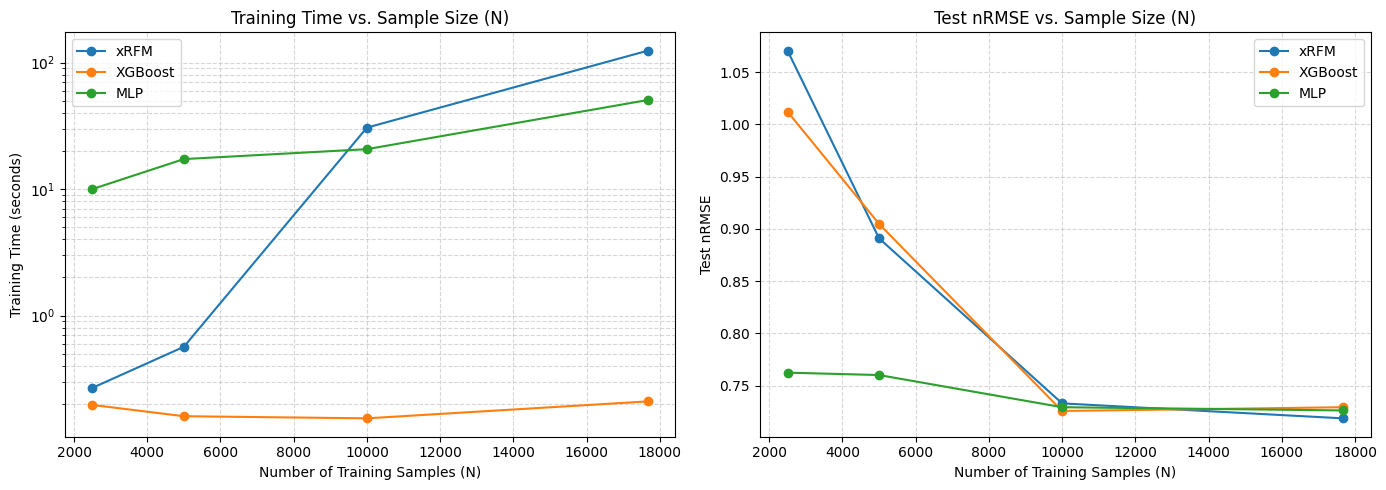

In [29]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in MODEL_SPECS:
    ax1.plot(sample_sizes, scale_results[name]["times"], marker="o", label=name)
ax1.set_title("Training Time vs. Sample Size (N)")
ax1.set_xlabel("Number of Training Samples (N)")
ax1.set_ylabel("Training Time (seconds)")
ax1.set_yscale("log")
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

for name in MODEL_SPECS:
    ax2.plot(sample_sizes, scale_results[name]["nrmses"], marker="o", label=name)
ax2.set_title("Test nRMSE vs. Sample Size (N)")
ax2.set_xlabel("Number of Training Samples (N)")
ax2.set_ylabel("Test nRMSE")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

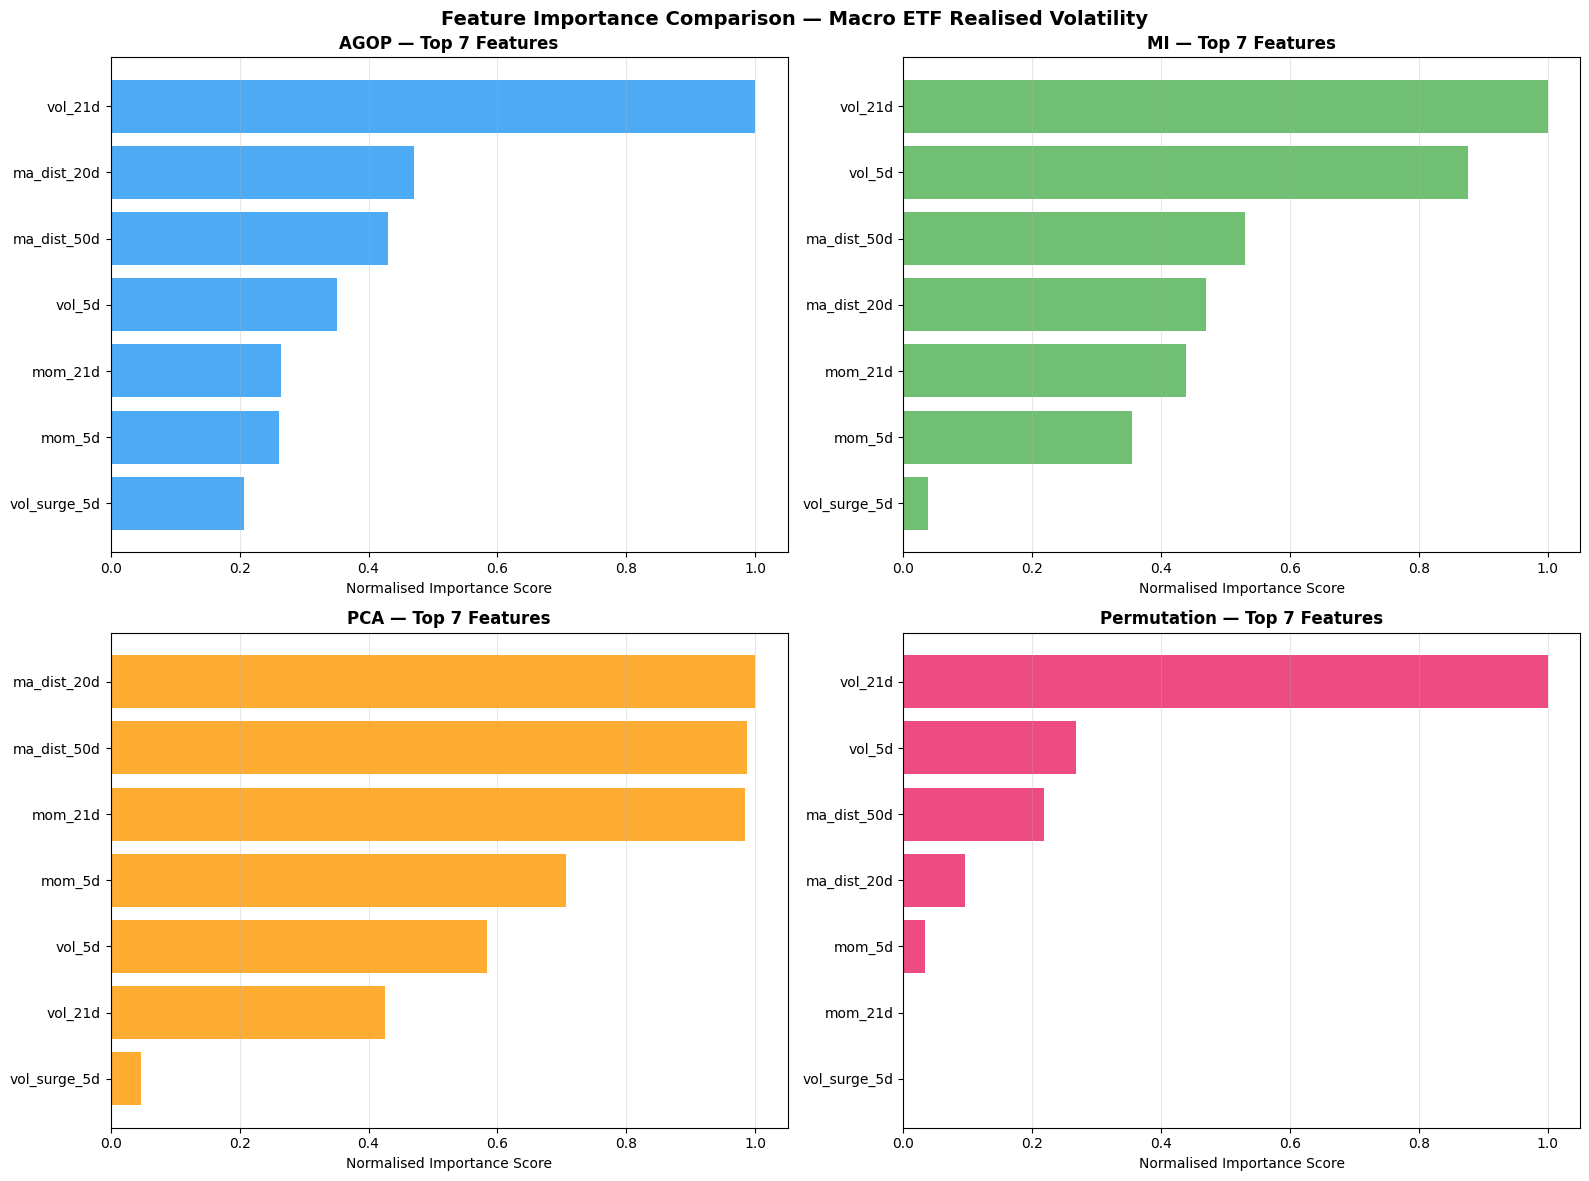

Saved interpretability_comparison.png

 Spearman Rank Correlation Between Methods
              AGOP     MI    PCA  Permutation
AGOP         1.000  0.857  0.357        0.821
MI           0.857  1.000  0.071        0.964
PCA          0.357  0.071  1.000        0.036
Permutation  0.821  0.964  0.036        1.000


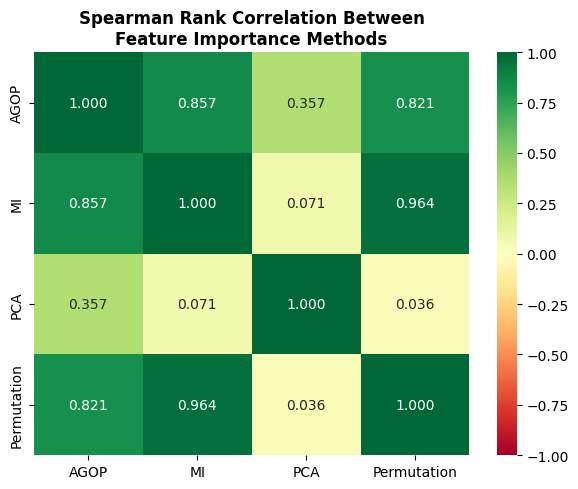

Saved rank_correlation_heatmap.png


In [30]:
#  Feature-importance comparison plot
import seaborn as sns
from scipy.stats import spearmanr

# Re-shape `interp_df` into the column layout the comparison plots expect.
importance_df = pd.DataFrame({
    "feature":     interp_df["Feature"].values,
    "AGOP":        interp_df["xRFM_AGOP_Diag"].values,
    "MI":          interp_df["Mutual_Info"].values,
    "PCA":         interp_df["PCA_Loading_PC1"].values,
    "Permutation": interp_df["XGB_Permutation"].values,
})

# Normalise each column to [0, 1] so the four panels share a comparable
# horizontal scale. AGOP is already normalised upstream -- no-op there.
methods = ["AGOP", "MI", "PCA", "Permutation"]
for col in methods:
    col_max = importance_df[col].abs().max()
    if col_max > 0:
        importance_df[col] = importance_df[col].abs() / col_max

#  Top-N bar charts, one per method
n_top  = min(10, len(importance_df))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Feature Importance Comparison \u2014 Macro ETF Realised Volatility",
             fontsize=14, fontweight="bold")

for ax, method, color in zip(axes.flatten(), methods, colors):
    top = importance_df.nlargest(n_top, method)
    ax.barh(top["feature"], top[method], color=color, alpha=0.8)
    ax.set_title(f"{method} \u2014 Top {n_top} Features", fontweight="bold")
    ax.set_xlabel("Normalised Importance Score")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("interpretability_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved interpretability_comparison.png")

#  Spearman rank correlation between methods
print("\n Spearman Rank Correlation Between Methods")
corr_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m1 in methods:
    for m2 in methods:
        corr, _ = spearmanr(importance_df[m1], importance_df[m2])
        corr_matrix.loc[m1, m2] = round(corr, 3)
print(corr_matrix)

#  Heatmap of rank correlations
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float),
            annot=True,
            fmt=".3f",
            cmap="RdYlGn",
            vmin=-1, vmax=1,
            ax=ax)
ax.set_title("Spearman Rank Correlation Between\nFeature Importance Methods",
             fontweight="bold")
plt.tight_layout()
plt.show()